# 누구에게 어떤 프로모션을 제공해야 할까요?

인과추론의 많은 문제는 평균 처치 효과(ATE)에 집중합니다. 예를 들어 “프로모션을 진행할 것인가, 하지 않을 것인가?”라는 질문은 모든 고객에게 동일한 프로모션을 제공하는 정책과 아무에게도 제공하지 않는 정책을 비교하는 문제입니다.

하지만 예산이 제한되어 있고 그 안에서 최대 효과를 내야 한다면 이야기가 달라집니다. 프로모션 효과가 고객마다 크게 다르다면, 모두에게 동일하게 제공하는 전략이 최선이 아닐 수 있습니다.

- 이미 구매할 고객(always-converters)에게 불필요한 비용을 쓰게 되고,
- 마케팅에 부정적으로 반응하는 고객(sleeping dogs) 때문에 오히려 손실이 발생하며,
- 효과가 클 고객(high-responders)을 제대로 우선순위에 두지 못해 잠재 매출을 놓칩니다.

따라서 핵심 질문은 다음과 같습니다.

_"어떤 고객에게 집중할 때 순이익이 가장 커질까?"_

정책학습(policy learning)은 가능한 처치 규칙들을 탐색하면서 전체 평균 순수익을 최대화하는 방법을 학습합니다. 즉, “누구를 처치해야 하는가?”라는 질문에 답하는 접근입니다.

<img src="./assets/AJStyles&Undertaker.jpg" width="500"/>

In [61]:
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

from econml.dr import DRLearner
from econml.policy import DRPolicyForest, DRPolicyTree

warnings.filterwarnings('ignore')

SEED = 1
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid')

## 정책학습 문제 정의

한 소프트웨어 판매 회사는 할인이나 기술지원 같은 인센티브가 고객의 소프트웨어 구매를 실제로 늘리는지, 그리고 어떤 고객에게 더 효과적인지 알고 싶어합니다.

이상적으로는 고객마다 서로 다른 인센티브를 무작위로 배정하는 실험(RCT)을 수행하는 것이 가장 좋지만 실제 비즈니스 환경에서는 비용 문제, 영업 전략, 대형 고객을 놓칠 위험 등으로 인해 무작위 실험을 수행하기 어렵습니다. 따라서 이번 데이터는 무작위 실험 데이터가 아닌 관찰 데이터(observational data)입니다.

데이터에는 약 2,000명의 고객 정보가 포함되어 있으며, 다음과 같은 변수들로 구성됩니다.

- 고객 특성: 각 고객의 산업 분야, 규모, 매출, 기술 프로필에 대한 세부 정보.
- 개입: 고객에게 제공된 인센티브에 대한 정보.
- 결과: 인센티브 제공 이후 1년 동안의 소프트웨어 구매 금액

| 변수명             | 타입 | 설명                                                             |
| --------------- | -- | -------------------------------------------------------------- |
| Global Flag     | X  | 고객이 글로벌 오피스(해외 지사)를 보유하고 있는지 여부                                |
| Major Flag      | X  | 고객이 해당 산업에서 대규모 소비 고객인지 여부 (SMC 또는 SMB와 구분)                    |
| SMC Flag        | X  | 고객이 중소기업(SMC, Small Medium Corporation)인지 여부 (Major 및 SMB와 구분) |
| Commercial Flag | X  | 고객의 사업 유형이 상업용(Commercial)인지 여부 (공공 부문과 구분)                    |
| IT Spend        | X  | IT 관련 구매에 사용한 금액                                               |
| Employee Count  | X  | 직원 수                                                           |
| PC Count        | X  | 고객이 사용하는 PC 수                                                  |
| Size            | X  | 연간 총매출 기준 고객 규모                                                |
| Tech Support    | T  | 고객이 기술 지원(Tech Support)을 받았는지 여부 (이진값)                         |
| Discount        | T  | 고객이 할인 혜택을 받았는지 여부 (이진값)                                       |
| Revenue         | Y  | 고객의 소프트웨어 구매 금액 기준 매출(Revenue)                                 |


`Tech Support`와 `Discount`는 모두 개입(intervention)이므로, 이를 조합해 다음과 같이 네 가지 처치로 정의합니다.

$$
A_i \in \{0, 1, 2, 3\}
$$

각 처치는 다음을 의미합니다.
- $A_i = 0$: 아무 개입도 제공하지 않음
- $A_i = 1$: 기술지원만 제공
- $A_i = 2$: 할인만 제공
- $A_i = 3$: 기술지원과 할인을 모두 제공

In [62]:
data = pd.read_csv('./data/multi_attribution_sample.csv')
data.columns = data.columns.str.strip()

covariates = [
    'Global Flag',
    'Major Flag',
    'SMC Flag',
    'Commercial Flag',
    'IT Spend',
    'Employee Count',
    'PC Count',
    'Size',
]
outcome = 'Revenue'

ARM_NAMES = {
    0: 'none',
    1: 'tech_support_only',
    2: 'discount_only',
    3: 'discount_plus_support',
}
ARM_LABELS = [ARM_NAMES[i] for i in range(4)]

required_columns = covariates + ['Tech Support', 'Discount', outcome]
for col in required_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

policy_df = data[required_columns].dropna().copy()
policy_df['arm'] = (
    2 * policy_df['Discount'].astype(int)
    + policy_df['Tech Support'].astype(int)
).astype(int)
policy_df['arm_name'] = policy_df['arm'].map(ARM_NAMES)

n = len(policy_df)
X = policy_df[covariates].to_numpy()
Y = policy_df[outcome].to_numpy(dtype=float)
A = policy_df['arm'].to_numpy(dtype=int)

print(policy_df.shape)
policy_df.head()


(2000, 13)


,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,arm,arm_name
0,1,0,1,0,45537,26,26,152205,0,1,17688.36300,2,discount_only
1,0,0,1,1,20842,107,70,159038,0,1,14981.43559,2,discount_only
2,0,0,0,1,82171,10,7,264935,1,1,32917.13894,3,discount_plus_support
3,0,0,0,0,30288,40,39,77522,1,1,14773.76855,3,discount_plus_support
4,0,0,1,0,25930,37,43,91446,1,1,17098.69823,3,discount_plus_support


### 비용 설정

실제 운영 환경에서는 인센티브 효과뿐 아니라 비용도 함께 고려해야 합니다. 또한 같은 인센티브라도 고객 특성에 따라 비용이 달라질 수 있습니다.

예를 들어 기술지원은 직원 수가 많은 기업일수록 더 많은 지원 시간이 필요할 수 있고, 할인 역시 규모가 큰 고객일수록 더 큰 할인 폭을 요구할 수 있습니다.

하지만 이 데이터에는 실제 비용 정보가 포함되어 있지 않기 때문에 고객 특성에 따라 달라지는 비용을 시뮬레이션해 사용합니다.

기술지원 비용은 직원 수가 많을수록 증가하도록 설정하고, 할인 비용은 고객 규모가 클수록 증가하도록 설정합니다.

이때 로그정규분포를 사용해 비용은 항상 양수이고, 일부 고객에서 큰 비용이 발생할 수 있는 현실적인 분포를 반영합니다.

$$
C_i(\text{tech}) \sim \text{LogNormal}(\log C_{\text{tech}} + 0.5 \cdot \tilde{e}_i,\ 0.3)
$$

$$
C_i(\text{disc}) \sim \text{LogNormal}(\log C_{\text{disc}} + 0.4 \cdot \tilde{s}_i,\ 0.3)
$$

여기서 $\tilde{e}_i$는 표준화된 직원 수, $\tilde{s}_i$는 표준화된 회사 규모입니다. 

이렇게 정의한 고객별 비용을 반영한 최종 순이익(net outcome)은 다음과 같습니다.

$$
Y_i^{net} = Y_i - C_i(A_i)
$$

이후 $Y_i^{net}$을 outcome으로 사용해 AIPW score를 계산하면, $\hat\Gamma_{i,a}$는 자연스럽게 $E[Y(a) - C(a) \mid X_i]$를 추정합니다. 따라서 AIPW 기반 정책학습과 평가가 자동으로 비용을 반영합니다.

In [63]:
COST_TECH_SUPPORT = 4_000.0   # baseline cost for tech support
COST_DISCOUNT     = 5_000.0   # baseline  cost for discount


rng_c = np.random.default_rng(SEED + 99)
emp_idx  = covariates.index('Employee Count')
size_idx = covariates.index('Size')

emp_z  = (X[:, emp_idx]  - X[:, emp_idx].mean())  / (X[:, emp_idx].std()  + 1e-8)
size_z = (X[:, size_idx] - X[:, size_idx].mean()) / (X[:, size_idx].std() + 1e-8)

# Tech support: 직원 수가 많을수록 더 많은 지원 비용 발생
c_tech = COST_TECH_SUPPORT * np.exp(0.5 * emp_z  + 0.3 * rng_c.standard_normal(len(policy_df)))
c_tech = np.clip(c_tech, 200.0, 40_000.0)

# Discount: 규모가 큰 기업일수록 더 큰 할인 비용 발생
c_disc = COST_DISCOUNT * np.exp(0.4 * size_z + 0.3 * rng_c.standard_normal(len(policy_df)))
c_disc = np.clip(c_disc, 200.0, 30_000.0)

C_obs = np.select(
    [A == 1, A == 2, A == 3],
    [c_tech, c_disc, c_tech + c_disc],
    default=0.0,
)

Y_net = Y - C_obs

pd.DataFrame({
    'arm': ARM_LABELS,
    'mean_cost':  [C_obs[A == a].mean() if (A == a).sum() > 0 else 0.0 for a in range(4)],
    'std_cost':   [C_obs[A == a].std()  if (A == a).sum() > 0 else 0.0 for a in range(4)],
    'mean_revenue':     [Y[A == a].mean()     for a in range(4)],
    'mean_net_revenue': [Y_net[A == a].mean() for a in range(4)],
})

,arm,mean_cost,std_cost,mean_revenue,mean_net_revenue
0,none,0.000000,0.000000,6585.891792,6585.891792
1,tech_support_only,5037.815894,4917.641358,15104.111534,10066.295640
2,discount_only,5181.570334,3043.343172,12247.935953,7066.365619
3,discount_plus_support,12665.283296,7375.490125,26784.124649,14118.841353


### 데이터 탐색 및 진단

정책학습에 들어가기 전에, 먼저 네 가지 처치 조합($A \in {0,1,2,3}$)에 대해 데이터의 구조를 점검합니다.

1. 처치별 표본 수: 각 처치에 충분한 관측치가 존재하는가?
2. 처치별 고객 특성 평균: 어떤 고객군이 특정 처치를 받는 경향이 있는가?
3. 처치별 Revenue 분포: Revenue의 규모, 분산, 이상치 분포가 처치마다 어떻게 다른가?
4. Positivity Check: 고객 특성 전반에서 각 처치가 충분히 함께 관측되는가?

In [64]:
arm_counts = policy_df['arm_name'].value_counts().reindex(ARM_LABELS).rename_axis('arm').to_frame('count')
arm_counts['share'] = arm_counts['count'] / len(policy_df)

display(arm_counts)

,count,share
arm,,
none,517,0.2585
tech_support_only,462,0.2310
discount_only,477,0.2385
discount_plus_support,544,0.2720


실제 표본 수는 `none` 517명, `tech_support_only` 462명, `discount_only` 477명, `discount_plus_support` 544명입니다. 각 처치의 비중은 23.1%에서 27.2% 사이로 비교적 고르게 분포되어 있으며, 특정 처치에 표본이 극단적으로 부족한 문제는 보이지 않습니다.

따라서 네 가지 처치를 비교하는 정책학습을 진행하기에 표본 분포는 안정적인 편입니다.

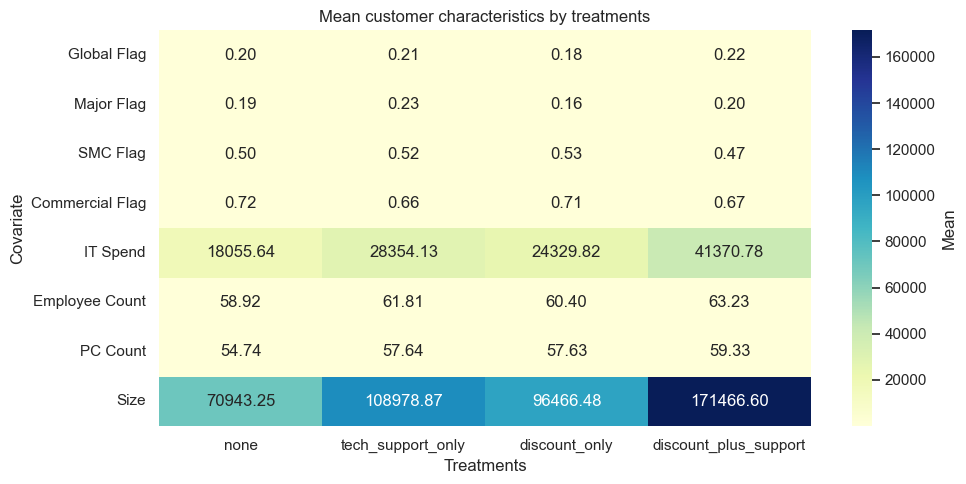

In [65]:
arm_covariate_means = (
    policy_df
    .groupby('arm_name')[covariates]
    .mean()
    .reindex(ARM_LABELS)
)

plt.figure(figsize=(10, 5))
sns.heatmap(arm_covariate_means.T, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean'})
plt.xlabel('Treatments')
plt.ylabel('Covariate')
plt.title('Mean customer characteristics by treatments')
plt.tight_layout()

처치별 고객 특성은 완전히 동일하지 않습니다. `Size` 평균은 `none` 그룹의 약 70,943에서 `discount_plus_support` 그룹의 약 171,467까지 큰 차이를 보이며, `IT Spend` 역시 약 18,056에서 41,371까지 차이가 납니다. 즉, 규모가 큰 고객일수록 기술지원과 할인을 함께 제공받는 경향이 있습니다.

이는 처치 배정이 고객 특성과 독립적이지 않음을 의미합니다. 따라서 이후 정책학습과 평가에서는 AIPW를 사용해 이러한 차이를 보정합니다.

,arm,arm_name,count,mean,median,std,min,max
0,0,none,517,6585.891792,6123.187067,3363.163462,-616.572451,21445.05937
1,1,tech_support_only,462,15104.111534,14483.719320,5400.319858,4619.491361,40166.67407
2,2,discount_only,477,12247.935953,10454.932500,7472.178476,889.975653,41818.39213
3,3,discount_plus_support,544,26784.124649,23560.252890,13124.968083,5903.906880,86006.92445


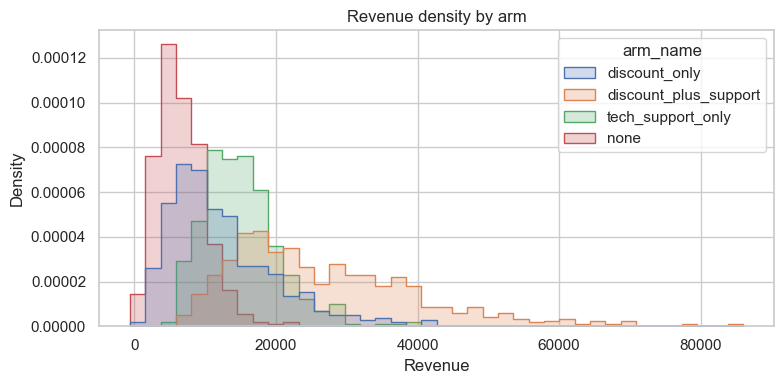

In [66]:
arm_revenue = (
    policy_df
    .groupby(['arm', 'arm_name'])[outcome]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)
display(arm_revenue)

plt.figure(figsize=(8, 4))

sns.histplot(
    data=policy_df,
    x=outcome,
    hue='arm_name',
    bins=40,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Revenue density by arm')
plt.tight_layout()
plt.show()

Revenue 평균은 `none` 약 6,586, `discount_only` 약 12,248, `tech_support_only` 약 15,104, `discount_plus_support` 약 26,784로 나타납니다.

앞서 확인했듯이 규모가 큰 고객일수록 더 강한 개입을 받는 경향이 있기 때문에 평균 차이를 그대로 정책을 평가하면 안 됩니다. 즉, Revenue 차이에는 고객 특성의 영향과 실제 처치 효과가 함께 섞여 있습니다.

따라서 단순 평균 비교만으로 정책을 판단하기보다는, 이후 AIPW 기반 정책 평가를 통해 비교해야 합니다.

### 식별 가정

관찰 데이터에서 AIPW 추정이 인과적으로 유효하려면 두 가지 가정이 필요합니다.

1. Unconfoundedness

    $$\{Y_i(0), Y_i(1), Y_i(2), Y_i(3)\} \perp A_i \mid X_i$$

    관측된 공변량 $X_i$를 조건부로 했을 때, 처치 배정은 잠재 결과와 독립이어야 합니다. 즉, 고객 규모, IT 지출, 직원 수 등의 변수들이 처치 배정을 충분히 설명한다고 가정합니다.

2. Positivity

    $$P(A_i = a \mid X_i = x) > 0 \quad \forall a \in \{0,1,2,3\},\ \forall x$$

    모든 고객 특성 범위에서 각 처치가 어느 정도 관측되어야 합니다.

이 중 Positivity는 propensity score를 추정해 직접 확인합니다.

$$
e_a(x) = P(A_i = a \mid X_i=x)
$$

추가로 propensity score가 극단적으로 치우쳐 있지 않은지도 확인합니다. 만약 특정 고객군에서 어떤 처치의 $e_a(x)$ 값이 0에 매우 가까우면, 일부 관측치에 지나치게 큰 가중치가 부여되어 추정이 불안정해질 수 있습니다.

### 데이터 분할

정책학습과 평가에 동일한 데이터를 사용하면 과대추정이 발생합니다. 이를 방지하기 위해 데이터를 train/test로 분리합니다. 정책은 train set으로 학습하고, 평가는 test set의 AIPW score로 수행합니다.

Positivity 확인을 위한 propensity 추정도 동일한 분할을 사용합니다.

In [67]:
idx = np.arange(len(policy_df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.5,
    stratify=A,
    random_state=SEED,
)

X_train = X[train_idx]
X_test = X[test_idx]
A_train = A[train_idx]
A_test = A[test_idx]

In [68]:
multi_propensity = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=20,
    random_state=SEED,
    n_jobs=1,
)
multi_propensity.fit(X_train, A_train)
e_hat_raw = multi_propensity.predict_proba(X_test)

propensity_summary = pd.DataFrame({
    'arm': ARM_LABELS,
    'mean_propensity': e_hat_raw.mean(axis=0),
    'min_propensity': e_hat_raw.min(axis=0),
    'p01_propensity': np.quantile(e_hat_raw, 0.01, axis=0),
    'propensity_below_0_05_rate': (e_hat_raw < 0.05).mean(axis=0),
})
display(propensity_summary)

,arm,mean_propensity,min_propensity,p01_propensity,propensity_below_0_05_rate
0,none,0.263941,0.057600,0.066831,0.0
1,tech_support_only,0.229863,0.126582,0.156283,0.0
2,discount_only,0.237934,0.125638,0.141322,0.0
3,discount_plus_support,0.268263,0.087299,0.101304,0.0


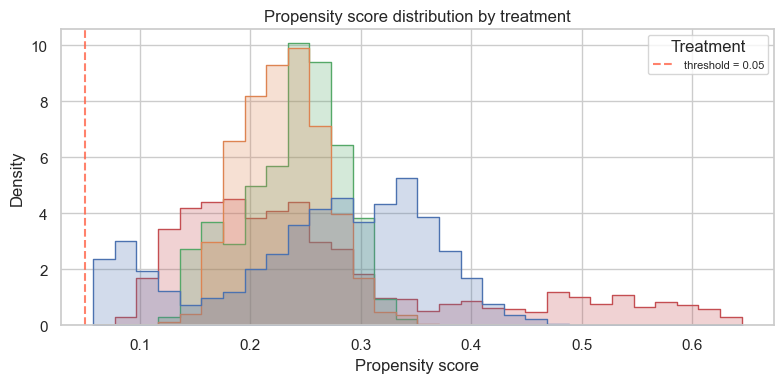

In [69]:
prop_df = pd.DataFrame(e_hat_raw, columns=ARM_LABELS)
prop_long = prop_df.melt(var_name='treatment', value_name='propensity')

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=prop_long, x='propensity', hue='treatment',
    bins=30, element='step', stat='density', common_norm=False, ax=ax,
)

ax.axvline(0.05, color='tomato', lw=1.5, ls='--', alpha=0.8, label='threshold = 0.05')
ax.legend(title='Treatment', fontsize=8)
ax.set_xlabel('Propensity score')
ax.set_ylabel('Density')
ax.set_title('Propensity score distribution by treatment')
plt.tight_layout()
plt.show()

이 데이터에서는 $\hat e_a(X_i)$의 최솟값이 약 0.058이며, `e_hat < 0.05`인 경우도 관측되지 않았습니다. 즉, 극단적으로 작은 propensity score로 인해 일부 관측치에 과도한 가중치가 부여되는 문제는 크지 않아 보입니다.

또한 그래프에서도 네 가지 처치의 propensity 분포가 전반적으로 잘 겹쳐 나타나므로, 뚜렷한 positivity 위반은 관찰되지 않습니다.

## 정책학습 방법론

세 가지 정책학습 방법을 비교합니다.

- Plug-in Policy (DRLearner)

    먼저 고객별 CATE를 추정한 뒤, 기대 순이익(net benefit)이 가장 큰 처치를 선택합니다.

    정책 형태에 제약이 없는 유연한 접근이지만, 최종 성능은 CATE 추정 품질에 크게 영향을 받습니다.

- DRPolicyTree

    DRPolicyTree는 AIPW score를 직접 최대화하도록 정책을 학습합니다.

    정책 구조를 얕은 decision tree로 제한하기 때문에, 결과를 if-then 규칙 형태로 해석할 수 있습니다. 따라서 정책 해석과 설명이 중요한 상황에서 유용합니다.

- DRPolicyForest

    DRPolicyForest 역시 AIPW score를 직접 최대화하지만, 단일 트리 대신 forest 구조를 사용합니다.

    단일 tree는 구조가 단순하지만 분산이 커질 수 있습니다. 반면 forest는 여러 트리의 결과를 평균적으로 활용하기 때문에 분산을 줄이면서 더 안정적으로 이질적인 처치 효과를 학습할 수 있습니다.

    대신 최종 정책을 하나의 명확한 if-then 규칙 형태로 해석하기는 더 어렵습니다.

세 정책은 모두 train set에서 학습하고, 동일한 test set의 AIPW score로 정책 가치를 비교합니다. 학습에 사용한 데이터로 정책을 평가하면 과대추정이 발생하므로, 학습과 평가에 서로 다른 데이터를 사용하는 것이 중요합니다.

## 평가 지표 구성

AIPW(Augmented Inverse Probability Weighting) score는 다음과 같이 정의합니다.

$$
\hat\Gamma_{i,a} = \hat\mu_a(X_i) + \frac{\mathbf{1}[A_i=a]}{\hat e_a(X_i)}\bigl(Y_i^{net} - \hat\mu_a(X_i)\bigr)
$$

- $\hat\mu_a(X_i)$: outcome model이 예측한 $E[Y^{net}(a)\mid X_i]$
- $\hat e_a(X_i)$: propensity model이 예측한 $P(A_i=a\mid X_i)$
- 두 번째 항은 실제 관측값과 예측값의 차이를 IPW로 보정하는 역할을 합니다.

이 구조 덕분에 outcome model과 propensity model 중 하나만 올바르게 추정되어도 불편성이 유지됩니다. 이를 doubly robust(이중 견고성)라고 부릅니다.

- outcome model이 정확하면: IPW 보정항의 기댓값이 0에 가까워져 $\hat\mu_a(X_i)$가 직접 기여합니다.
- propensity model이 정확하면: IPW 보정항이 outcome model의 편향을 제거합니다.

이 score는 정책학습(DRPolicyTree/Forest)과 정책 평가 모두에서 사용합니다.

In [70]:
Y_net_train = Y_net[train_idx]
Y_net_test  = Y_net[test_idx]

e_hat_net = np.clip(e_hat_raw, 0.02, 0.98)
e_hat_net = e_hat_net / e_hat_net.sum(axis=1, keepdims=True)

gamma_net = np.zeros((len(X_test), 4))
mu_hat_net = np.zeros((len(X_test), 4))

for arm_id in range(4):
    outcome_model = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    )
    outcome_model.fit(X_train[A_train == arm_id], Y_net_train[A_train == arm_id])
    mu_a = outcome_model.predict(X_test)
    observed_a = (A_test == arm_id).astype(float)

    gamma_net[:, arm_id] = mu_a + observed_a / e_hat_net[:, arm_id] * (Y_net_test - mu_a)
    mu_hat_net[:, arm_id] = mu_a

In [71]:
sample_ids = np.arange(5)

sample_prediction_table = pd.concat(
    {
        'sample': pd.DataFrame({
            'sample_id': sample_ids,
            'actual_arm': pd.Series(A_test[sample_ids]).map(ARM_NAMES).to_numpy(),
            'observed_net_outcome': Y_net_test[sample_ids],
        }),
        'e_hat': pd.DataFrame(e_hat_net[sample_ids], columns=ARM_LABELS),
        'mu_hat': pd.DataFrame(mu_hat_net[sample_ids], columns=ARM_LABELS),
        'gamma': pd.DataFrame(gamma_net[sample_ids], columns=ARM_LABELS),
    },
    axis=1,
)

sample_prediction_table

sample                                                 e_hat  \
  sample_id             actual_arm observed_net_outcome      none   
0         0  discount_plus_support          9254.558541  0.248633   
1         1      tech_support_only          7702.861662  0.211087   
2         2      tech_support_only          5062.184420  0.376570   
3         3                   none          8930.495022  0.339653   
4         4                   none          8156.575502  0.312265   

                                                               mu_hat  \
  tech_support_only discount_only discount_plus_support          none   
0          0.267338      0.272366              0.211662   5370.099281   
1          0.307204      0.243394              0.238315  10468.942522   
2          0.241901      0.256261              0.125268   2879.741786   
3          0.194701      0.246505              0.219142   8458.779217   
4          0.250021      0.312123              0.125590  10137.469821   

                                                                gamma  \
  tech_support_only discount_only discount_plus_support          none   
0       9559.777763   4547.484552           6984.731609   5370.099281   
1       6728.988419   8373.316633          11121.826609  10468.942522   
2       5449.409859    937.515103           2959.514347   2879.741786   
3       8254.372069   6054.598973           6560.028069   9847.598052   
4       3378.748035   5743.802939           2988.217314   3793.845054   

                                                         
  tech_support_only discount_only discount_plus_support  
0       9559.777763   4547.484552          17708.540116  
1       9899.108508   8373.316633          11121.826609  
2       3848.652052    937.515103           2959.514347  
3       8254.372069   6054.598973           6560.028069  
4       3378.748035   5743.802939           2988.217314

### Plug-in Policy

Plug-in policy는 먼저 고객별 처치 효과(CATE)를 추정한 뒤, 그 값을 이용해 정책을 만드는 방식입니다.

Binary treatment에서는 일반적으로 $\hat\tau(x) > 0$이면 처치하고, 비용이 있으면 $\hat\tau(x) > c(x)$일 때 처치합니다.

여러 처치가 있는 경우에는 baseline 처치와의 상대효과를 비교합니다. 여기서는 `none`(처치 없음)을 baseline으로 두고, `DRLearner`로 다음 값을 추정합니다.

$$
\hat\tau_a(x) = \widehat{\mathbb{E}}[Y^{net}(a) - Y^{net}(0) \mid X=x]
\qquad a \in \{1,2,3\}
$$

baseline 처치의 상대효과는 0이므로, 고객별로 다음 네 값을 비교합니다.

$$
[0, \hat\tau_1(x), \hat\tau_2(x), \hat\tau_3(x)]
$$

그리고 가장 큰 값을 갖는 처치를 선택합니다.

$$
\hat\pi_{plugin}(x) = \arg\max_{a \in \{0,1,2,3\}} \widehat{\mathbb{E}}[Y^{net}(a) - Y^{net}(0) \mid X=x]
$$

이 방식은 직관적이고 유연하지만, CATE 추정 품질에 크게 영향을 받습니다. 따라서 학습된 정책은 별도의 test set에서 AIPW value로 평가합니다.

> **주의**: "각 고객의 $\hat\Gamma_{i,a}$ 중 가장 큰 arm을 선택하면 되지 않나?"라고 생각할 수 있습니다. 그러나 AIPW score는 개별 관측치 수준에서 분산이 매우 크기 때문에, pointwise argmax로 만든 정책은 노이즈에 과적합됩니다. AIPW score는 반드시 집계된 형태로 사용해야 합니다. 정책 평가(value 추정, 비용 곡선 등)처럼 여러 관측치를 합산하거나, DRPolicyTree/Forest처럼 노드 단위 평균을 최적화하거나, DRLearner처럼 pseudo-outcome으로 회귀하는 방식이 그 예입니다.

In [72]:
dr_cate = DRLearner(
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_final=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
)
dr_cate.fit(Y_net_train, A_train, X=X_train)

# none을 baseline으로, 나머지 처치별 E[Y_net(a) - Y_net(0) | X] 반환
cate_vs_none = dr_cate.const_marginal_effect(X_test)
plugin_arm_values = np.column_stack([
    np.zeros(len(X_test)),  # none: baseline, 상대효과 = 0
    cate_vs_none,
])
pi_plugin = np.argmax(plugin_arm_values, axis=1)

In [73]:
pd.Series(pi_plugin).map(ARM_NAMES).value_counts(normalize=True).reindex(ARM_LABELS).fillna(0)

none                     0.092
tech_support_only        0.500
discount_only            0.035
discount_plus_support    0.373
Name: proportion, dtype: float64

In [74]:
none_idx = np.where(pi_plugin == 0)[0][:3]
tech_idx = np.where(pi_plugin == 1)[0][:3]
both_idx = np.where(pi_plugin == 3)[0][:3]
sample_ids = np.concatenate([none_idx, tech_idx, both_idx])

df_plugin_sample = pd.DataFrame(X_test[sample_ids], columns=covariates)[['Size', 'Employee Count', 'IT Spend']]
df_plugin_sample['assigned_arm'] = pd.Series(pi_plugin[sample_ids]).map(ARM_NAMES).values
df_plugin_sample[['τ_tech', 'τ_disc', 'τ_both']] = np.round(cate_vs_none[sample_ids], 0).astype(int)
df_plugin_sample.index = pd.RangeIndex(len(df_plugin_sample))
df_plugin_sample

,Size,Employee Count,IT Spend,assigned_arm,τ_tech,τ_disc,τ_both
0,96204,142,17655,none,-6140,-1419,-1719
1,25390,178,7971,none,-14556,-4252,-7232
2,66555,279,19899,none,-17629,-2896,-16582
3,70868,20,26263,tech_support_only,4265,-40,4155
4,24152,18,4610,tech_support_only,4174,-2316,-771
5,54855,63,14772,tech_support_only,2042,-698,553
6,399228,36,133052,discount_plus_support,7849,-1281,11819
7,181704,24,59529,discount_plus_support,9158,5216,10248
8,294377,37,112485,discount_plus_support,7134,858,9048


plug-in 정책은 약 50% 고객에게 `tech_support_only`, 37% 고객에게 `discount_plus_support`, 그리고 약 9% 고객에게 `none`을 배정합니다.

비용을 함께 고려하면서, 기대 순이익이 음수로 예상되는 일부 고객에게는 처치를 하지 않는 선택이 나타납니다.

### Policy Tree

현업에서는 성능뿐 아니라 정책의 설명 가능성도 중요한 경우가 많습니다. 얕은 decision tree 기반 정책은 다음과 같은 이유로 실무에서 자주 사용됩니다.

- **이해관계자 설명**: 직관적인 분기 규칙 형태라 정책을 쉽게 설명하고 공유할 수 있습니다.
- **공정성 검토**: 어떤 고객이 어떤 처치를 받는지 구조가 명확해 편향 여부를 점검하기 쉽습니다.
- **운영 안정성**: 복잡한 모델보다 단순한 규칙 기반 정책이 실제 운영과 관리 측면에서 안정적입니다.

이 경우 정책을 모든 가능한 함수에서 찾는 대신, 제한된 정책 클래스 $\Pi$ 안에서 탐색합니다.

$$
\hat\pi = \arg\max_{\pi \in \Pi}
\frac{1}{n}\sum_{i=1}^{n} \widehat\Gamma_{i,\pi(X_i)}
$$

Policy Tree는 $\Pi$를 얕은 decision tree로 제한합니다. 따라서 depth를 작게 두면 사람이 읽을 수 있는 형태로 정책을 해석할 수 있습니다. 여기서는 `econml`의 `DRPolicyTree`를 사용합니다.

또한 leaf가 지나치게 작아지면 다중 처치 환경에서 value 추정이 불안정해질 수 있으므로, `min_samples_leaf`를 사용해 너무 작은 leaf를 방지합니다.

In [75]:
dr_policy_tree = DRPolicyTree(
    max_depth=2,
    min_samples_leaf=30,
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
)
dr_policy_tree.fit(Y_net_train, A_train, X=X_train)
pi_tree = dr_policy_tree.predict(X_test).astype(int).ravel()

pd.Series(pi_tree).map(ARM_NAMES).value_counts(normalize=True).reindex(ARM_LABELS).fillna(0)


none                     0.199
tech_support_only        0.475
discount_only            0.000
discount_plus_support    0.326
Name: proportion, dtype: float64

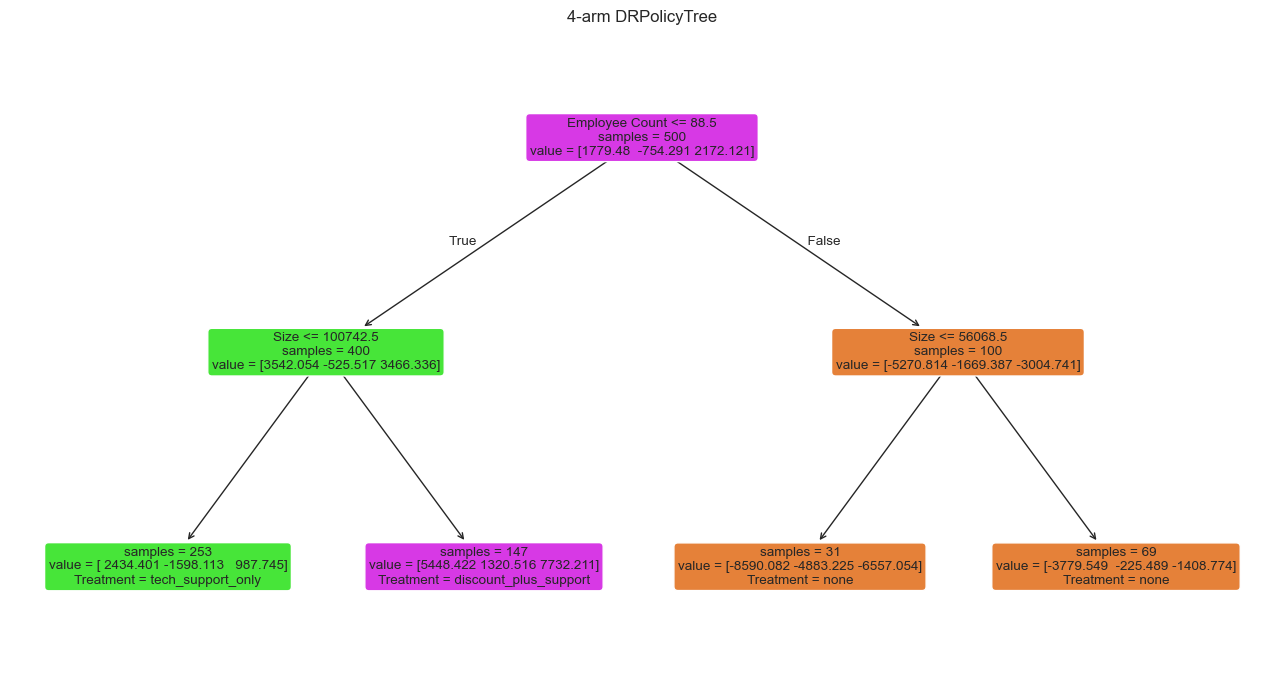

In [76]:
fig, ax = plt.subplots(figsize=(13, 7))
dr_policy_tree.plot(feature_names=covariates, treatment_names=ARM_LABELS, ax=ax)
ax.set_title('4-arm DRPolicyTree')
plt.tight_layout()

이 트리 정책은 주로 `Size`를 기준으로 고객을 나눕니다. 특징적으로 약 20%의 고객에게는 `none`을 배정합니다. 비용을 반영한 결과, 일부 고객은 처치했을 때 기대 순이익이 낮아 처치하지 않는 편이 더 낫다고 판단한 것입니다.

전체적으로는 규모가 큰 고객에게 `discount_plus_support`를, 그 외 고객에게는 주로 `tech_support_only`를 배정합니다. 기대 순이익이 낮은 고객에게는 `none`을 선택합니다.

### Policy Forest

Policy Forest는 여러 개의 tree를 활용해 보다 안정적으로 정책을 학습합니다.

Policy Forest 역시 AIPW score를 직접 최대화하지만, 단일 tree 대신 여러 tree의 결과를 평균적으로 활용하기 때문에 분산이 더 작고 복잡한 이질성을 더 안정적으로 학습할 수 있습니다.

여기서는 `econml`의 `DRPolicyForest`를 사용합니다.

다만 tree 기반 정책처럼 하나의 명확한 의사결정 규칙 형태로 해석하기는 어렵습니다. 학습 이후에는 동일한 test set의 AIPW score를 사용해 정책 가치를 비교합니다.

In [77]:
dr_policy_forest = DRPolicyForest(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=30,
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
    n_jobs=1,
)
dr_policy_forest.fit(Y_net_train, A_train, X=X_train)
pi_forest = dr_policy_forest.predict(X_test).astype(int).ravel()

pd.Series(pi_forest).map(ARM_NAMES).value_counts(normalize=True).reindex(ARM_LABELS).fillna(0)


none                     0.113
tech_support_only        0.471
discount_only            0.000
discount_plus_support    0.416
Name: proportion, dtype: float64

DRPolicyForest는 전반적으로 plug-in 정책과 유사한 배정을 보입니다. `none` 11%, `tech_support_only` 47%, `discount_plus_support` 42%로, plug-in 정책보다 `discount_plus_support` 비중이 조금 더 높게 나타납니다.

## 정책 평가

이제 학습된 정책들을 동일한 test set의 AIPW score 기준으로 비교합니다.

비교를 위해 모든 고객에게 동일한 처치를 적용하는 baseline 정책도 함께 사용합니다.

- `all_none`
- `all_tech_support_only`
- `all_discount_only`
- `all_discount_plus_support`

예를 들어 `all_discount_plus_support`는 모든 고객에게 기술지원과 할인을 함께 제공했을 때의 평균 순이익을 의미합니다.

반면 학습된 정책은 고객 특성 $X_i$에 따라 서로 다른 처치를 배정합니다.

만약 학습된 정책의 value가 가장 좋은 baseline 정책보다 높다면, 모든 고객에게 동일한 처치를 적용하는 것보다 고객별 targeting이 더 효과적이라는 의미입니다.

In [78]:
policy_assignments = {
    **{f'all_{arm_name}': np.full(len(X_test), arm_id) for arm_id, arm_name in ARM_NAMES.items()},
    'plugin_drlearner_4arm': pi_plugin,
    'dr_policy_tree_4arm': pi_tree,
    'dr_policy_forest_4arm': pi_forest,
}

eval_rows = []
for policy_name, policy_assignment in policy_assignments.items():
    pi = np.asarray(policy_assignment).astype(int).ravel()
    scores = gamma_net[np.arange(len(pi)), pi]

    row = {
        'policy': policy_name,
        'value': scores.mean(),
        'value_se': scores.std(ddof=1) / np.sqrt(len(scores)),
    }
    for arm_id, arm_name in ARM_NAMES.items():
        row[f'rate_{arm_name}'] = np.mean(pi == arm_id)
    eval_rows.append(row)

policy_eval = pd.DataFrame(eval_rows)
policy_eval['ci_lower'] = policy_eval['value'] - 1.96 * policy_eval['value_se']
policy_eval['ci_upper'] = policy_eval['value'] + 1.96 * policy_eval['value_se']

display_cols = ['policy', 'value', 'ci_lower', 'ci_upper'] + [f'rate_{n}' for n in ARM_LABELS]
policy_eval.sort_values('value', ascending=False)[display_cols]

,policy,value,ci_lower,ci_upper,rate_none,rate_tech_support_only,rate_discount_only,rate_discount_plus_support
4,plugin_drlearner_4arm,11810.377712,11283.561563,12337.193861,0.092,0.500,0.035,0.373
6,dr_policy_forest_4arm,11625.627540,11102.022589,12149.232491,0.113,0.471,0.000,0.416
5,dr_policy_tree_4arm,11148.462369,10700.609230,11596.315508,0.199,0.475,0.000,0.326
1,all_tech_support_only,10526.523876,9833.034751,11220.013001,0.000,1.000,0.000,0.000
3,all_discount_plus_support,10136.708882,9439.445941,10833.971824,0.000,0.000,0.000,1.000
2,all_discount_only,7545.079205,6993.536621,8096.621788,0.000,0.000,1.000,0.000
0,all_none,7249.345467,6955.447432,7543.243502,1.000,0.000,0.000,0.000


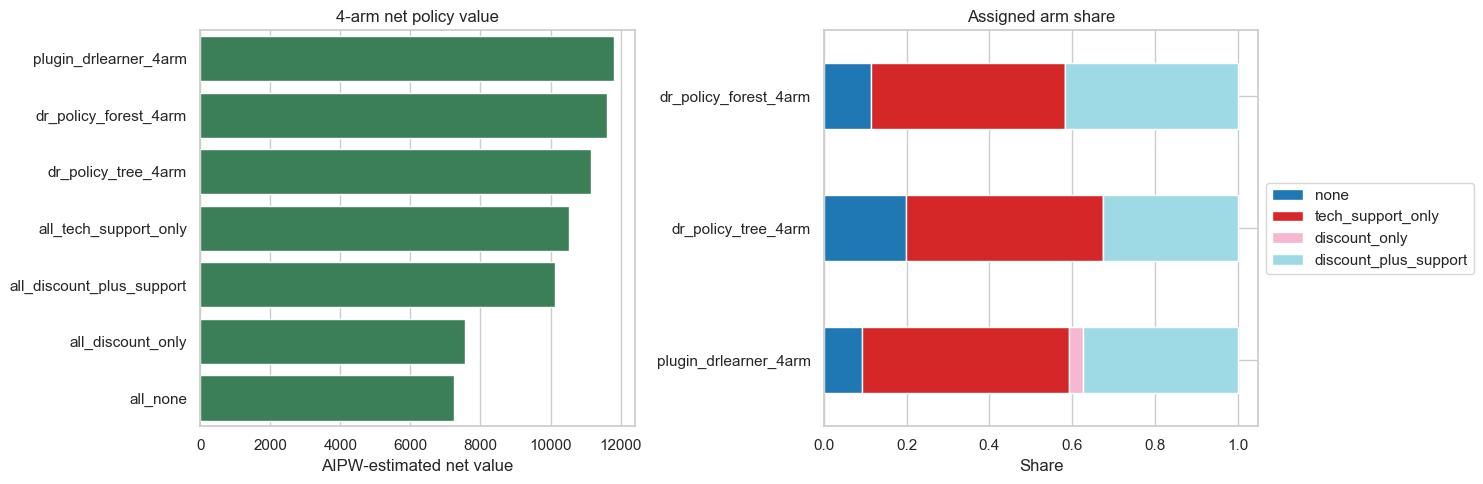

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = policy_eval.sort_values('value', ascending=False)
sns.barplot(data=plot_df, x='value', y='policy', ax=axes[0], color='seagreen')
axes[0].set_title('4-arm net policy value')
axes[0].set_xlabel('AIPW-estimated net value')
axes[0].set_ylabel('')

arm_rate_cols = [f'rate_{name}' for name in ARM_LABELS]
rate_df = policy_eval.set_index('policy')[arm_rate_cols]
rate_df.columns = ARM_LABELS
rate_df.loc[['plugin_drlearner_4arm', 'dr_policy_tree_4arm', 'dr_policy_forest_4arm']].plot(kind='barh', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Assigned arm share')
axes[1].set_xlabel('Share')
axes[1].set_ylabel('')
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

세 학습 정책 모두 단일 처치 정책보다 높은 가치를 가집니다. 고객별로 처치를 다르게 배정하는 것이 모두에게 같은 처치를 적용하는 것보다 효과적이라는 의미입니다.

학습 정책 중에서는 DRLearner plug-in(11,810)이 가장 높았고, DRPolicyForest(11,626)와 DRPolicyTree(11,148)가 뒤를 이었습니다. 다만 plug-in과 forest는 신뢰구간이 상당 부분 겹쳐 실질적인 차이가 있다고 보기는 어렵습니다. 이론적으로는 AIPW score를 직접 최적화하는 DR 정책이 더 유리할 수 있지만, 실제로는 표본 크기나 데이터 특성에 따라 결과가 달라집니다. tree 정책은 해석 가능한 구조를 유지하는 대신 성능을 일부 내준 모습입니다.

단일 처치 정책에서는 `all_tech_support_only`(10,527)가 가장 좋았습니다. `all_discount_plus_support`(10,137)는 할인 비용이 고객 규모에 따라 커지도록 설정했기 때문에, 일부 고객에서는 할인 편익이 비용을 충분히 상쇄하지 못한 것으로 보입니다.

## 예산 제약 하의 정책 비교

지금까지는 어떤 정책이 전체적으로 더 높은 AIPW value를 갖는지 비교했습니다. 그러나 실제 환경에서는 예산이 제한되어 있을 수 있습니다. 같은 예산 안에서 어떤 정책이 더 효율적인지 비교하려면 비용 곡선(cost curve)이 유용합니다.

### 고객별 기대 비용 추정

이를 위해 먼저 고객별 $E[C(a) \mid X_i]$를 추정합니다. 실제 비용은 해당 고객이 받은 처치에서만 관측되므로, 처치별로 훈련 데이터에서 비용 회귀 모델을 학습해 test set에 적용합니다.

In [80]:
# 처치별 E[C(a) | X] 추정
# c_hat_test[i, a] = 고객 i가 처치 a를 받을 때의 예측 비용
c_true_by_arm = {1: c_tech, 2: c_disc, 3: c_tech + c_disc}

c_hat_test = np.zeros((len(X_test), 4))   # 처치 0 → 비용 = 0
for arm_id in [1, 2, 3]:
    mask_train = (A_train == arm_id)
    mdl = RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                                random_state=SEED, n_jobs=1)
    mdl.fit(X_train[mask_train], c_true_by_arm[arm_id][train_idx[mask_train]])
    c_hat_test[:, arm_id] = np.maximum(mdl.predict(X_test), 200.0)

print("Estimated E[C(a)|X] — test set (mean ± std):")
for arm_id, arm_name in ARM_NAMES.items():
    if arm_id > 0:
        print(f"  {arm_name:25s}: {c_hat_test[:, arm_id].mean():8,.0f} ± {c_hat_test[:, arm_id].std():6,.0f}")

Estimated E[C(a)|X] — test set (mean ± std):
  tech_support_only        :    4,892 ±  3,466
  discount_only            :    5,454 ±  2,330
  discount_plus_support    :   10,687 ±  4,139


### 비용 곡선과 예산 제약 하 비교

비용 곡선의 두 축은 다음과 같습니다.

- **x축**: 고객 1인당 누적 평균 처치 비용
- **y축**: 고객 1인당 누적 평균 순수익 — baseline(`none`) 대비 증분이며, **비용이 이미 차감된 값**입니다.

각 정책에서 편익/비용 비율 $\hat\rho(x) = \hat\tau(x) / \hat\gamma(x)$이 높은 고객부터 순서대로 처치합니다. x = B에서 세로선을 그으면 예산 B 하의 정책 비교가 됩니다. 같은 예산에서 y값이 높을수록 더 효율적인 정책입니다.

그래프의 종점(●)은 각 정책의 처치 대상 전원을 처치했을 때의 위치입니다. `none`으로 배정된 고객은 처치 비용이 없으므로 곡선에 포함되지 않습니다.

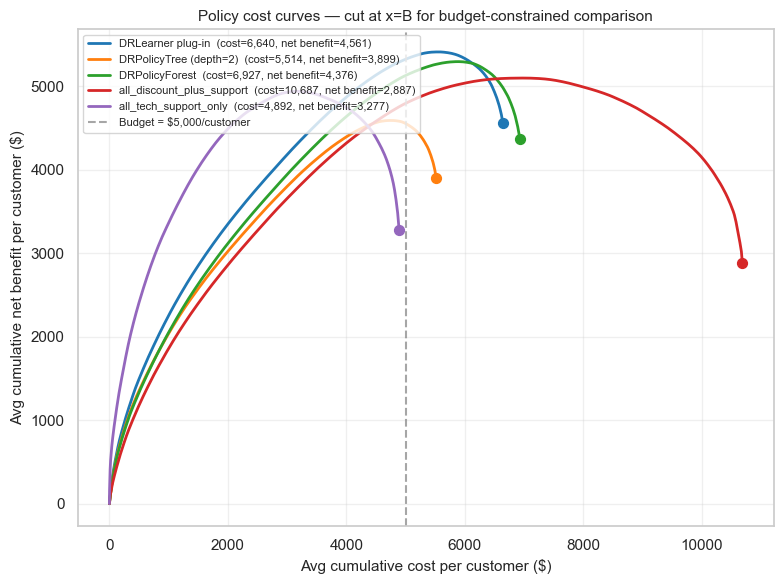

In [81]:
def policy_cost_curve(pi_eval, gamma_matrix, c_hat_matrix):
    """
    처치별 고객 비용 추정값을 사용해 비용 곡선을 생성합니다.
    c_hat_matrix[i, a] = Ê[C(a) | X_i]

    x = 고객 1인당 누적 평균 처치 비용 (gross)
    y = 고객 1인당 누적 평균 순이익 (Y_net에 비용이 이미 차감된 값)
      → x + y = 무처치 대비 총 매출 증분

    처치 고객은 순이익 / 추정 비용 비율(내림차순)로 정렬합니다.
    """
    pi = np.asarray(pi_eval).ravel().astype(int)
    n = len(pi)
    treated = pi > 0
    if treated.sum() == 0:
        return np.array([0.0]), np.array([0.0])

    benefit = gamma_matrix[np.arange(n), pi] - gamma_matrix[:, 0]
    cost    = c_hat_matrix[np.arange(n), pi].astype(float)

    b_t, c_t = benefit[treated], cost[treated]
    ratio = np.where(c_t > 0, b_t / c_t, b_t)
    order = np.argsort(-ratio)

    cum_cost    = np.r_[0, np.cumsum(c_t[order])]
    cum_benefit = np.r_[0, np.cumsum(b_t[order])]
    return cum_cost / n, cum_benefit / n


n_test = len(X_test)
policies_curve = [
    ('DRLearner plug-in',         pi_plugin),
    ('DRPolicyTree (depth=2)',     pi_tree),
    ('DRPolicyForest',            pi_forest),
    ('all_discount_plus_support', np.full(n_test, 3)),
    ('all_tech_support_only',     np.full(n_test, 1)),
]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for (name, pi_eval), color in zip(policies_curve, colors):
    cc, cg = policy_cost_curve(pi_eval, gamma_net, c_hat_test)
    ax.plot(cc, cg, lw=2, color=color,
            label=f'{name}  (cost={cc[-1]:,.0f}, net benefit={cg[-1]:,.0f})')
    ax.scatter([cc[-1]], [cg[-1]], s=50, color=color, zorder=5)

budget_example = 5_000
ax.axvline(budget_example, color='gray', lw=1.5, ls='--', alpha=0.7,
           label=f'Budget = ${budget_example:,}/customer')

ax.set_xlabel('Avg cumulative cost per customer ($)', fontsize=11)
ax.set_ylabel('Avg cumulative net benefit per customer ($)', fontsize=11)
ax.set_title('Policy cost curves — cut at x=B for budget-constrained comparison', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

예산 규모에 따라 효과적인 정책이 다릅니다. 예산이 $1,000~$3,000 수준으로 적을 때는 `all_tech_support_only`가 가장 효율적입니다. 기술지원 평균 비용이 낮아 소규모 예산으로도 편익/비용 비율이 높은 고객부터 빠르게 처치할 수 있기 때문입니다.

예산이 $4,000~$6,000 수준으로 늘어나면 학습 정책(plug-in, forest)이 앞서기 시작합니다. 고객별 최적 처치를 배정하는 타겟팅 효과가 발휘되며, 같은 비용으로 더 높은 순이익을 냅니다.

예산을 전부 소진하는 상황에서도 학습 정책이 가장 효율적입니다. plug-in은 약 $6,600을 써서 $4,561, forest는 약 $6,900을 써서 $4,376의 순이익을 냅니다. 반면 `all_discount_plus_support`는 $10,700을 전부 소진해도 순이익이 $2,887에 그쳐 예산 대비 효율이 가장 낮습니다.

세 정책 모두 무처치 대비 통계적으로 유의하게 높은 value를 보였습니다 (95% CI가 모두 0을 포함하지 않음).

최선 상수 정책(`tech_support_only`) 대비에서는 정책별로 차이가 있습니다. `DRLearner plug-in`(+1,284, CI: [622, 1,946])과 `DRPolicyForest`(+1,099, CI: [426, 1,772])는 통계적으로 유의하게 우수합니다. 반면 `DRPolicyTree`(+622, CI: [-1, 1,245])는 점추정치는 양수이지만, 신뢰구간 하한이 0에 근접해 단일 처치 정책 대비 우위가 통계적으로 명확하지 않습니다.

## 참고 자료

- [Stanford ML+CI Tutorial — Policy Learning I (Binary Treatment)](https://bookdown.org/stanfordgsbsilab/ml-ci-tutorial/policy-learning-i---binary-treatment.html)
- [Athey and Wager (2021, Econometrica) — Policy Learning with Observational Data](https://onlinelibrary.wiley.com/doi/abs/10.3982/ECTA15732)
- [Sun, Du, Wager et al. (2021) — Treatment Allocation under Uncertain Costs](https://arxiv.org/abs/2103.11066)
- [Imai and Li (2019) — Experimental Evaluation of Individualized Treatment Rules](https://arxiv.org/pdf/1905.05389.pdf)
- [arXiv 2604.06123](https://arxiv.org/html/2604.06123v1)